Bài tập 1

Câu hỏi 1: Sử dụng hàm .shape, hãy xác định số lượng đối tượng (quan sát) và số lượng đặc trưng (biến).

Câu hỏi 2: Hãy liệt kê những đặc trưng nào trong tập dữ liệu là số thực (continuous) và những đặc trưng nào là phân loại (categorical).

Câu hỏi 3: Trong bài toán này, biến mục tiêu (target) là giá của kim cương (price). Hãy vẽ hai biểu đồ cạnh nhau (trên cùng một dòng):

Biểu đồ histogram phân phối của biến mục tiêu (price)

Biểu đồ histogram phân phối của logarithm của biến mục tiêu (log price)

Yêu cầu: Số bin = 100; Đặt tiêu đề/ghi chú cho từng biểu đồ; Đặt giới hạn trục hoành (set_xlim(5, 10)) cho biểu đồ log

Câu hỏi: Nên sử dụng biến nào để dự đoán tốt hơn: biến gốc (price) hay biến log (log price)?

Câu hỏi 4. Dataset chứa các đặc trưng phân loại (categorical features). Hãy phân tích số lượng giá trị duy nhất của các đặc trưng cut, color, clarity. Có các category hiếm (rare categories) trong dataset không? Tỷ lệ của các category trong cấu trúc tổng thể của mỗi đặc trưng là bao nhiêu?


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


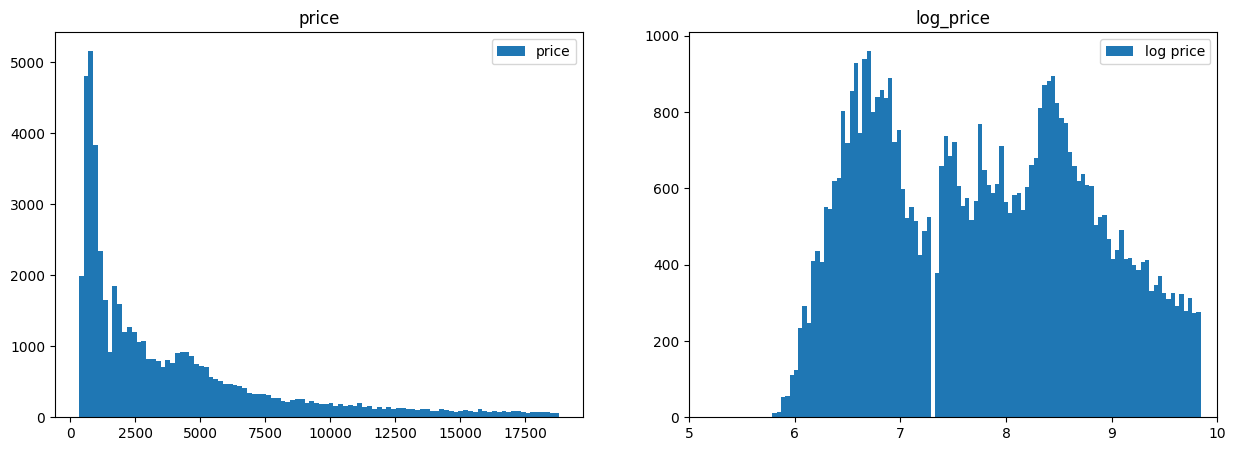

In [ ]:
import pandas as pd
data= pd.read_csv('/content/diamonds.csv')

#1
data.shape
#2
data.dtypes
data.info() # float: carat, depth, table, x,y,z, price
# categorical: cut, color, clarity

#3
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset('diamonds')
bins = 100
fig,ax = plt.subplots(nrows= 1, ncols = 2, figsize =(15,5)) #tham soos figsize nhan vao 1 tuple gom do lon cua fig va axes
ax[0].hist(data['price'],bins, label = 'price' ) #hist la method tao bieu do histogram nhu minh thuong hay dung bieu do plot
ax[0].set_title('price')
ax[1].hist(np.log1p(data['price']),bins, label = 'log price')
ax[1].set_title('log_price')
ax[1].set_xlim(5,10)
ax[1].legend()
ax[0].legend()
fig.show()
# fig.tight_layout

# Лучше использовать график log(price), так как он ближе к нормальному распределению, что облегчает анализ,
# a график price имеет правостороннюю асимметрию (смещение влево), что затрудняет анализ

In [ ]:
#4
for feature in ['cut', 'color', 'clarity']:
    unique_count = data[feature].nunique() #dem so categorical trong feature
    unique_values = data[feature].unique() #liet ke cac categorical trong feature
    print(f"{feature}: {unique_count} giá trị-{unique_values}")
    counts = data[feature].value_counts()
    percentages_min = min(counts/len(data[feature]))
    print(percentages_min)
    percentages = counts/len(data[feature])
    print(percentages)

cut: 5 giá trị-['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
0.029847979236188357
cut
Ideal        0.399537
Premium      0.255673
Very Good    0.223990
Good         0.090953
Fair         0.029848
Name: count, dtype: float64
color: 7 giá trị-['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']
0.05205784204671857
color
G    0.209344
E    0.181628
F    0.176900
H    0.153949
D    0.125603
I    0.100519
J    0.052058
Name: count, dtype: float64
clarity: 8 giá trị-['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']
0.013737486095661847
clarity
SI1     0.242214
VS2     0.227253
SI2     0.170449
VS1     0.151483
VVS2    0.093919
VVS1    0.067760
IF      0.033185
I1      0.013737
Name: count, dtype: float64


Bài tập 2. Chuẩn bị dữ liệu.

Câu hỏi 5. Thêm cột log_price vào dataset. Trong bài toán, chúng ta sẽ mô hình hóa logarit của giá.

Câu hỏi 6. Mã hóa các categorical features thành nhị phân bằng OneHotEncoder. Thêm các đặc trưng đã được mã hóa vào dataframe (đồng thời xóa các đặc trưng phân loại gốc và price). Ngoài ra, trong dataset còn có đặc trưng depth, được tính toán dựa trên các đặc trưng khác: x, y, z. Hãy xóa cả đặc trưng này. Số lượng đặc trưng đã thay đổi như thế nào so với kích thước mẫu ban đầu?

Bài tập 3. Xây dựng mô hình.

Câu hỏi 7. Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra theo tỷ lệ 8:2. Chuẩn hóa (standardize) dữ liệu định lượng. Trên dữ liệu tập huấn luyện, huấn luyện hồi quy tuyến tính với các tham số mặc định. Đánh giá chất lượng của nó trên tập kiểm tra dựa trên MSE. Xác định các đặc trưng ít quan trọng nhất và quan trọng nhất.

In [ ]:
import pandas as pd
data= pd.read_csv('/content/diamonds.csv')
# 5
data['log_price'] = np.log1p(data['price'])
# 6
from sklearn.preprocessing import OneHotEncoder, StandardScaler
encoder = OneHotEncoder(sparse_output=False)
nominal_features = encoder.fit_transform(data[['cut', 'color','clarity']])
feature_names = encoder.get_feature_names_out(['cut', 'color', 'clarity'])
df = pd.DataFrame(nominal_features,columns = feature_names)
data= pd.concat([data,df],axis=1)

data = data.drop(['cut', 'color','clarity','depth','Unnamed: 0','price'],axis=1)
print(data.head())

#solumns : 11 -> 26

# 7
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

x = data.drop('log_price', axis =1)
y = data['log_price']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42)
scaler = StandardScaler()
scaler.fit_transform(x_train)
scaler.transform(x_test)

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('MSE:{}'.format(mean_squared_error(y_test,y_pred)))
print('MAE:{}'.format(mean_absolute_error(y_test,y_pred)))
print('R2:{}'.format(r2_score(y_test,y_pred)))

# sorted_weights = sorted(zip(model.coef_.ravel(), range(x_train.shape[1])),
#                        key=lambda x: abs(x[0]),
#                        reverse=True)
# weights = [x[0] for x in sorted_weights]
# features = [f'Feature_{x[1]}' for x in sorted_weights]  # Tự động đặt tên
# df = pd.DataFrame({'features': features, 'weights': weights})
# ax = df.plot.barh(x='features', y='weights', rot=0)

#xay dung ridge lasso
param = {'alpha': np.linspace(100,750,80)}
model1 = GridSearchCV(
    estimator = Ridge(),
    param_grid= param,
    cv = 5
)
model1.fit(x_train,y_train)
y_rid_predict = model1.predict(x_test)
print('MSE Ridge : {}'.format(mean_squared_error(y_test,y_rid_predict)))
print(model1.best_params_)
print(model1.best_estimator_.coef_)

param = {'alpha': [pow(10,i) for i in range(-5,1)]}
model2 = GridSearchCV(
    estimator = Lasso(),
    param_grid = param,
    cv= 5
)
model2.fit(x_train,y_train)
y_las_predict = model2.predict(x_test)
print('MSE Lasso : {}'.format(mean_squared_error(y_test,y_las_predict)))
print(model2.best_params_)
print(model2.best_estimator_.coef_)

# kết luận: sau khi xây dựng hồi quy tt ta thấy r2 rất tốt trên bộ test: 97%, thông thường ko cần thử thêm ridge lasso nữa, dùng ridge lasso
# là khi r2 trên bộ train cho kqua tốt mà trên bộ test cho kqua tồi; nhưng ở đây ta học cách dùng, đo MSE ta thấy MSE của ridge lasso tăng một chút hồi quy tt
# cho MSE = 0.02 thì 2 cái kia cho 0.03 nói chung ko cải thiện nhiều, cơ bản r2 hồi quy tt đã rất tốt rồi;
# lasso ridge tốt là MSE trên bộ test giảm còn bộ train MSE tăng chút cx đc vì bản chất là làm giảm độ fit khi train và tốt khi đưa đi dự đoán

   carat  table     x     y     z  log_price  cut_Fair  cut_Good  cut_Ideal  \
0   0.23   55.0  3.95  3.98  2.43   5.789960       0.0       0.0        1.0   
1   0.21   61.0  3.89  3.84  2.31   5.789960       0.0       0.0        0.0   
2   0.23   65.0  4.05  4.07  2.31   5.793014       0.0       1.0        0.0   
3   0.29   58.0  4.20  4.23  2.63   5.814131       0.0       0.0        0.0   
4   0.31   58.0  4.34  4.35  2.75   5.817111       0.0       1.0        0.0   

   cut_Premium  ...  color_I  color_J  clarity_I1  clarity_IF  clarity_SI1  \
0          0.0  ...      0.0      0.0         0.0         0.0          0.0   
1          1.0  ...      0.0      0.0         0.0         0.0          1.0   
2          0.0  ...      0.0      0.0         0.0         0.0          0.0   
3          1.0  ...      1.0      0.0         0.0         0.0          0.0   
4          0.0  ...      0.0      1.0         0.0         0.0          0.0   

   clarity_SI2  clarity_VS1  clarity_VS2  clarity_VVS1  